In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv("customer_support_tickets.csv")

print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [4]:
df.shape
df.info()
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy


     -------------------------------------- 15.4/15.4 MB 692.1 kB/s eta 0:00:00
     ------------------------------------- 472.3/472.3 kB 58.8 kB/s eta 0:00:00
     -------------------------------------- 40.1/40.1 kB 100.5 kB/s eta 0:00:00
     ------------------------------------ 122.7/122.7 kB 180.0 kB/s eta 0:00:00
     ------------------------------------ 122.0/122.0 kB 550.3 kB/s eta 0:00:00
     -------------------------------------- 50.7/50.7 kB 172.2 kB/s eta 0:00:00
     ---------------------------------------- 1.8/1.8 MB 1.9 MB/s eta 0:00:00
     ------------------------------------ 651.7/651.7 kB 912.4 kB/s eta 0:00:00
     ---------------------------------------- 2.1/2.1 MB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 6.2/6.2 MB 1.8 MB/s eta 0:00:00
     -------------------------------------- 63.2/63.2 kB 854.4 kB/s eta 0:00:00
     -------------------------------------- 73.5/73.5 kB 405.6 kB/s eta 0:00:00
     ----------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...


True

In [7]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 12.8/12.8 MB 1.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk
import spacy

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Importing Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [11]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [12]:
nlp = spacy.load("en_core_web_sm")

In [13]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8469, 17)


In [14]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (8469, 17)


In [15]:
df.describe(include='object')

,Customer Name,Customer Email,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
count,8469,8469,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769
unique,8028,8320,3,42,730,5,16,8077,3,2769,4,4,5470,2728
top,Michael Garcia,bsmith@example.com,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42
freq,5,4,2896,240,24,1752,576,25,2881,1,2192,2143,3,3


Check Unique Values in Each Column

In [16]:
for column in df.columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(df[column].nunique())


Ticket ID
8469

Customer Name
8028

Customer Email
8320

Customer Age
53

Customer Gender
3

Product Purchased
42

Date of Purchase
730

Ticket Type
5

Ticket Subject
16

Ticket Description
8077

Ticket Status
3

Resolution
2769

Ticket Priority
4

Ticket Channel
4

First Response Time
5470

Time to Resolution
2728

Customer Satisfaction Rating
5


Check Missing Value Percentage

In [17]:
missing = (df.isnull().sum() / len(df)) * 100

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing
})

missing

,Missing Values,Percentage
Ticket ID,0,0.000000
Customer Name,0,0.000000
Customer Email,0,0.000000
Customer Age,0,0.000000
Customer Gender,0,0.000000
Product Purchased,0,0.000000
Date of Purchase,0,0.000000
Ticket Type,0,0.000000
Ticket Subject,0,0.000000
Ticket Description,0,0.000000


In [19]:
df.info()
df.isnull().sum()
df=df.drop_duplicates()
df.shape
df["Ticket Type"].value_counts()
df["Ticket Priority"].value_counts()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

Medium      2192
Critical    2129
High        2085
Low         2063
Name: Ticket Priority, dtype: int64

Text Cleaning

In [22]:
stop_words=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()

In [23]:
def clean_text(text):

    text=str(text)

    text=text.lower()

    text=re.sub(r"http\S+","",text)

    text=re.sub(r"\d+","",text)

    text=text.translate(str.maketrans('','',string.punctuation))

    words=word_tokenize(text)

    words=[word for word in words if word not in stop_words]

    words=[lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
df["Clean_Text"]=df["Ticket Description"].apply(clean_text)
df[["Ticket Description","Clean_Text"]].head()

,Ticket Description,Clean_Text
0,I'm having an issue with the {product_purchase...,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,im issue productpurchased please assist note s...


TF-IDF

In [25]:
vectorizer=TfidfVectorizer(max_features=5000)
X=vectorizer.fit_transform(df["Clean_Text"])
y=df["Ticket Type"]
# train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Model Training

In [27]:
model=MultinomialNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

print(classification_report(y_test,y_pred))

Accuracy : 0.1871310507674144
                      precision    recall  f1-score   support

     Billing inquiry       0.13      0.04      0.06       357
Cancellation request       0.18      0.17      0.17       327
     Product inquiry       0.15      0.12      0.13       316
      Refund request       0.20      0.32      0.24       345
     Technical issue       0.21      0.29      0.24       349

            accuracy                           0.19      1694
           macro avg       0.17      0.19      0.17      1694
        weighted avg       0.17      0.19      0.17      1694



Confusion Matrix

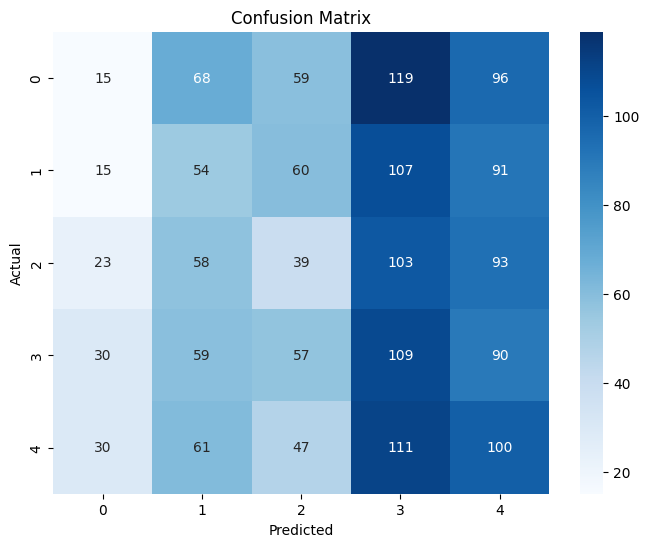

In [28]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Predicting new ticket

In [29]:
new_ticket=["I cannot login to my account after resetting my password"]

clean=clean_text(new_ticket[0])

vector=vectorizer.transform([clean])

prediction=model.predict(vector)

print("Predicted Ticket Type :",prediction[0])

Predicted Ticket Type : Refund request
